<a href="https://colab.research.google.com/github/andyotani/Machine-learning_26-27/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 2

In [25]:
!pip install ipywidgets

In [26]:
# Langkah 1 - Ilustrasi Data Non-Linier
# Langkah 1a - Import Library
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

In [27]:
# Langkah 1b - Buat Kembali Fungsi Plotting
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

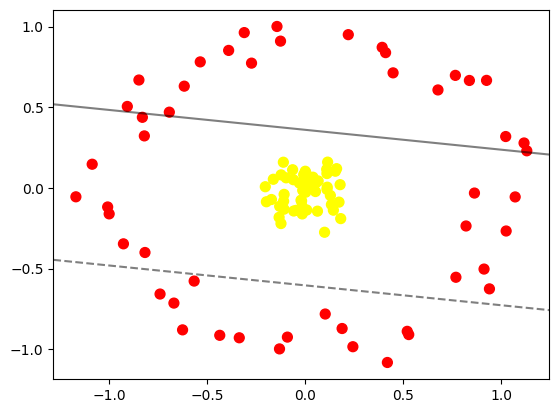

In [28]:
# Langkah 1c - Buat Data Dummy Non-Linier
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [29]:
r = np.exp(-(X**2).sum(1))

In [30]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-1.25615917e-01,  9.10056353e-01],
       [ 8.38142188e-01,  6.66187299e-01],
       [ 3.97547129e-02,  3.69618600e-03],
       [-9.27228047e-01, -3.46608970e-01],
       [ 1.02343413e+00,  3.18592790e-01],
       [ 9.25707644e-01,  6.66739922e-01],
       [-1.97712681e-01, -8.57621498e-02],
       [ 4.48758461e-01,  7.13371391e-01],
       [ 2.43576850e-01, -9.84461875e-01],
       [ 6.28845639e-02, -1.44086741e-01],
       [ 2.83389778e-03, -2.65456619e-02],
       [-1.32817656e-01, -1.82185083e-01],
       [-4.52411496e-02, -1.39078209e-01],
       [ 1.78420570e-01,  2.01318054e-02],
       [-6.69641722e-01, -7.13997363e-01],
       [-3.10701323e-01,  9.63018515e-01],
       [-1.09786142e-01, -8.22223229e-02],
       [ 1.54320151e-01,  1.03564231e-01],
       [ 1.11341770e-01, -8.98954273e-03],
       [-7.40397637e-01, -6.57864836e-01],
       [ 8.21013052e-01, -2.35987752e-01],
       [-1.80975425e-02, -8.08281221e-02],
       [-6.93075155e-01,  4.69669614e-01],
       [-8.48229427e-01,  6.68979753e-01],
       [-6.00519830e-02,  5.08636724e-02],
       [ 6.64088467e-02,  4.32515978e-02],
       [ 8.14463104e-03, -1.36826162e-01],
       [-3.90351451e-01,  8.52517789e-01],
       [-1.00002507e+00, -1.60899550e-01],
       [-2.03311909e-01,  7.43435823e-03],
       [ 1.44055065e-01, -1.38034130e-01],
       [ 4.19686956e-01, -1.08216703e+00],
       [-1.23042214e-02, -1.50351244e-02],
       [ 7.01240919e-04,  1.61659326e-03],
       [ 1.11709000e+00,  2.78589934e-01],
       [ 5.79045502e-02,  3.51420003e-02],
       [-1.11201732e-01,  1.59320967e-01],
       [ 1.13109752e+00,  2.30125478e-01],
       [-1.29884664e-01, -1.13928173e-01],
       [-8.30598850e-01,  4.37783302e-01],
       [-1.71939764e-01, -7.18299441e-02],
       [-2.10813062e-02, -7.61646525e-02],
       [-9.05326257e-02, -9.24884951e-01],
       [-1.16982182e+00, -5.50847199e-02],
       [ 4.10468497e-01,  8.38753269e-01],
       [ 1.34060011e-01, -1.03328060e-01],
       [-6.16896512e-01,  6.30840399e-01],
       [-9.70047108e-02,  6.26670709e-02],
       [-5.81137956e-02, -1.43204008e-01],
       [-7.41529631e-03,  8.21537377e-02],
       [-1.23278231e-01, -2.20901717e-01],
       [ 9.90825909e-02, -2.74850779e-01],
       [ 1.88636712e-01, -8.71575372e-01],
       [-6.25446688e-01, -8.79960855e-01],
       [ 8.58049251e-03,  3.76642376e-02],
       [ 7.69342809e-01, -5.53840266e-01],
       [ 1.02501094e-01, -7.81779159e-01],
       [-6.38160140e-02,  1.12736317e-01],
       [ 7.18772977e-04,  1.03388778e-01],
       [ 5.28667378e-01, -9.09186386e-01],
       [-2.73573246e-01,  7.73617431e-01],
       [ 1.11169952e-01,  8.90869782e-02],
       [-1.07347415e-01, -3.99395044e-02],
       [ 1.60563321e-01,  1.19357398e-01],
       [ 5.20936415e-01, -8.89088350e-01],
       [-1.22729504e-01,  8.08619313e-02],
       [-9.07439666e-01,  5.05104828e-01],
       [ 2.20137083e-01,  9.50174105e-01],
       [-1.43727859e-01,  1.00089128e+00],
       [ 1.28684457e-01, -4.68390114e-02],
       [ 6.77784501e-01,  6.07450861e-01],
       [-1.00765992e+00, -1.18083656e-01],
       [ 9.12897762e-01, -5.03078731e-01],
       [ 1.10034178e-01,  1.15285196e-01],
       [-1.62409449e-01,  5.36205790e-02],
       [ 7.66577871e-01,  6.97800905e-01],
       [ 1.81523200e-01, -1.90248599e-01],
       [ 1.12782556e-01,  4.54233987e-03],
       [ 8.63946422e-01, -3.18207220e-02],
       [ 9.40474587e-01, -6.25777495e-01],
       [-3.36126573e-01, -9.29077649e-01],
       [-4.35687341e-01, -9.13754095e-01],
       [-8.17277109e-01, -4.00341687e-01],
       [ 3.71762292e-03,  9.35539380e-02],
       [-5.35282242e-01,  7.81388556e-01],
       [-1.08132927e-01, -1.31900089e-01],
       [-1.30823269e-01, -9.97999470e-01],
       [ 5.26268198e-02, -2.23620392e-02],
       [-8.20544854e-01,  3.22474726e-01],
       [-1.08668914e+00,  1.46902756e-01],
       [-2.93437169e-02,  3.05598058e-02],
       [ 3.93097556e-01,  8.71571025e-01

In [31]:
# Langkah 2 - Fitting Model
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

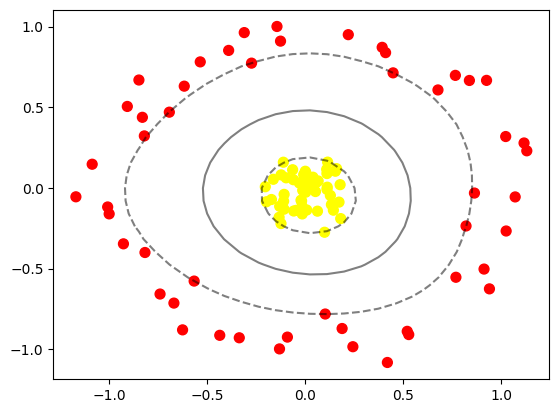

In [32]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')